# Corporate Wallet Digital Twin V3 — executed judging notebook

**Team:** Corporate Wallet Digital Twin  
**Member:** Christopher Koen  
**Snapshot:** 30 June 2026  
**Build:** V3.0 / 10 August 2026

V3 reconstructs the latent corporate financial system from one bank's partial observations, then optimizes decisions and evidence acquisition under uncertainty.

> **Claim boundary:** Syn Bank activity is simulated; public facts are E1; priors and calibration panels are representative. Reconstructed external flows are **scenarios, not measured competitor transactions**. Commercial values are not bank-approved and causal incremental value is withheld.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from wallet_twin_v3.repository import repository

v3 = json.loads((ROOT / 'dashboard/app/data/v3-fixture.json').read_text(encoding='utf-8'))
v2 = json.loads((ROOT / 'dashboard/app/data/shadow-fixture.json').read_text(encoding='utf-8'))
print(f"Loaded {len(repository.opportunities)} live V3 model objects and {len(v3['opportunities'])} exported contract records.")
print(v3['metadata']['watermark'])

Loaded 100 live V3 model objects and 100 exported contract records.
SYN BANK SIMULATION + PUBLIC E1 + REPRESENTATIVE PRIORS — RECONSTRUCTED COMPETITOR FLOWS ARE NOT MEASURED


## 1. Deterministic V3 validation boundary

This table verifies the implemented mechanics. It does not substitute for E3 calibration, approved bank economics or qualified RM outcomes.

In [2]:
validation = pd.DataFrame([
    ('Client-product opportunities', v3['validation']['opportunities'], 'replayed'),
    ('Portfolio clients', v3['validation']['clients'], 'replayed'),
    ('Shadow-wallet edges', v3['validation']['shadow_flow_edges'], 'mass balanced'),
    ('Maximum balance error (ZAR)', v3['validation']['max_mass_balance_error_zar'], 'must equal zero'),
    ('PU labelled positives', v3['validation']['pu_labelled_positives'], 'positive–unlabelled'),
    ('Change-point series', v3['validation']['change_point_series'], 'representative replay'),
    ('Selected RM actions', v3['validation']['rm_actions_selected'], 'capacity respected'),
    ('Selected evidence requests', v3['validation']['positive_net_voi_requests'], 'all net-positive'),
    ('Measured competitor-share claims', v3['validation']['measured_competitor_share_claims'], 'must equal zero'),
    ('Causal-value claims', v3['validation']['causal_value_claims'], 'must equal zero'),
], columns=['check', 'value', 'interpretation'])
display(validation)
assert v3['validation']['max_mass_balance_error_zar'] == 0
assert v3['validation']['anonymous_provider_nodes_only']
assert v3['validation']['measured_competitor_share_claims'] == 0
assert v3['validation']['causal_value_claims'] == 0

,check,value,interpretation
0,Client-product opportunities,100.0,replayed
1,Portfolio clients,20.0,replayed
2,Shadow-wallet edges,1500.0,mass balanced
3,Maximum balance error (ZAR),0.0,must equal zero
4,PU labelled positives,33.0,positive–unlabelled
5,Change-point series,100.0,representative replay
6,Selected RM actions,12.0,capacity respected
7,Selected evidence requests,8.0,all net-positive
8,Measured competitor-share claims,0.0,must equal zero
9,Causal-value claims,0.0,must equal zero


## 2. Shadow Wallet reconstruction — Glencore Trade Finance

The posterior wallet interval constrains total mass. Entropy-regularised Sinkhorn transport distributes the latent component over corridor priors and anonymous provider nodes. The equality below is exact by construction, while every external edge remains `SCENARIO` / `RECONSTRUCTED_NOT_MEASURED`.

In [3]:
glencore = next(o for o in v3['opportunities'] if o['opportunity_id'] == 'E02-trade-finance')
s = glencore['shadow_wallet']
shadow_summary = pd.DataFrame({
    'metric': ['Observed Syn Bank flow', 'Latent external wallet', 'Total wallet', 'Scenario bank share', 'Network entropy'],
    'lower': [s['observed_bank_flow'], s['latent_external_wallet']['lower'], s['total_wallet']['lower'], s['bank_share']['lower'], np.nan],
    'median': [s['observed_bank_flow'], s['latent_external_wallet']['median'], s['total_wallet']['median'], s['bank_share']['median'], s['normalized_entropy']],
    'upper': [s['observed_bank_flow'], s['latent_external_wallet']['upper'], s['total_wallet']['upper'], s['bank_share']['upper'], np.nan],
})
display(shadow_summary)

balance_error = abs(s['total_wallet']['median'] - s['observed_bank_flow'] - s['latent_external_wallet']['median'])
print(f"Median mass-balance error: R{balance_error:,.2f}")
print(f"Measurement status: {s['measurement_status']} | Draws: {s['ensemble_draws']}")
assert balance_error < 0.01
assert all(not flow['observed_by_bank'] for flow in s['flows'])
assert all(flow['provider_node'].startswith('External provider ') for flow in s['flows'])

,metric,lower,median,upper
0,Observed Syn Bank flow,1.085074e+09,1.085074e+09,1.085074e+09
1,Latent external wallet,7.518289e+09,1.390623e+10,3.492286e+10
2,Total wallet,8.603362e+09,1.499130e+10,3.600793e+10
3,Scenario bank share,3.013429e-02,7.238021e-02,1.261220e-01
4,Network entropy,NaN,8.133161e-01,NaN


Median mass-balance error: R0.00
Measurement status: RECONSTRUCTED_NOT_MEASURED | Draws: 256


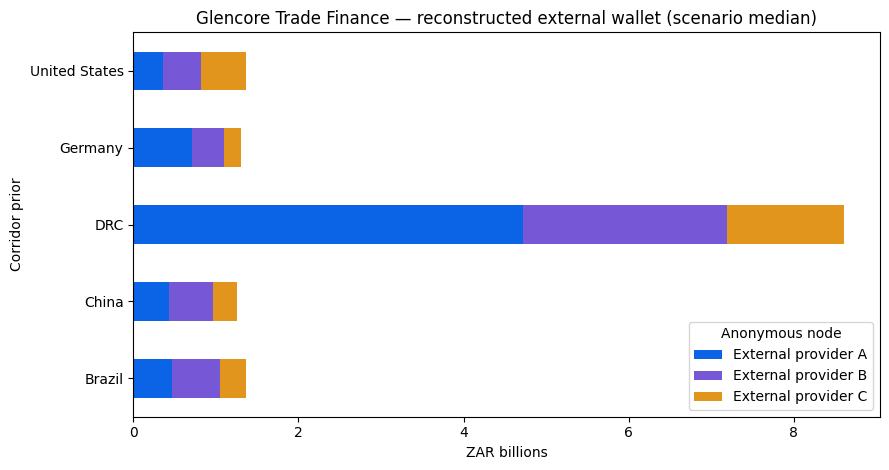

In [4]:
flow_df = pd.DataFrame(s['flows'])
flow_df['median_zar_bn'] = flow_df['amount'].map(lambda x: x['median'] / 1e9)
pivot = flow_df.pivot_table(index='corridor', columns='provider_node', values='median_zar_bn', aggfunc='sum')
pivot.plot(kind='barh', stacked=True, figsize=(9, 4.8), color=['#0B63E5', '#7658D6', '#E2951C'])
plt.title('Glencore Trade Finance — reconstructed external wallet (scenario median)')
plt.xlabel('ZAR billions')
plt.ylabel('Corridor prior')
plt.legend(title='Anonymous node', loc='lower right')
plt.tight_layout()
plt.show()

## 3. Positive–Unlabelled need and Bayesian change-points

The Elkan–Noto correction estimates product need when only selected positives are labelled. It retains the SCAR assumption and selection constant. Bayesian run-length filtering then surfaces timing shifts. A leakage alarm is a verification signal—not proof of a competitor transfer.

In [5]:
need_rows = [{
    'client': o['entity_name'], 'product': o['product'],
    'need_probability': o['need']['product_need_probability'],
    'labelled_positive': o['need']['positive_label_observed'],
    'selection_constant': o['need']['selection_constant'],
} for o in v3['opportunities']]
needs = pd.DataFrame(need_rows).sort_values(['need_probability','client'], ascending=[False, True])
display(needs.head(12))
print('SCAR assumptions:', '; '.join(glencore['need']['assumptions']))

,client,product,need_probability,labelled_positive,selection_constant
2,BHP Group,Trade finance,1.0,True,0.700318
7,BHP Group,Collections,1.0,True,0.700318
8,BHP Group,Liquidity,1.0,True,0.700318
12,BHP Group,Payments,1.0,True,0.700318
3,Bid Corporation,Cross-border FX,1.0,True,0.700318
6,Bid Corporation,Liquidity,1.0,True,0.700318
9,Bid Corporation,Trade finance,1.0,True,0.700318
18,Bid Corporation,Payments,1.0,True,0.700318
1,Glencore,Trade finance,1.0,True,0.700318
0,MTN Group,Cross-border FX,1.0,True,0.700318


SCAR assumptions: selected positives are correct; SCAR: positive labelling is conditionally independent of features; unlabelled cases may contain latent positives; representative fixture results do not establish bank-population calibration


In [6]:
leakage_rows = [{
    'client': o['entity_name'], 'product': o['product'],
    'alarm_probability': o['leakage']['alarm_probability'],
    'observed_decline': o['leakage']['observed_level_decline'],
    'recent_peak_cp': o['change_point']['recent_peak_probability'],
    'event_90d': o['change_point']['probability_90d'],
    'status': o['leakage']['measurement_status'],
} for o in v3['opportunities']]
leakage = pd.DataFrame(leakage_rows).sort_values('alarm_probability', ascending=False)
display(leakage.head(12))
assert leakage['status'].eq('MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE').all()

,client,product,alarm_probability,observed_decline,recent_peak_cp,event_90d,status
69,Naspers,Trade finance,0.241141,0.000000,0.688973,0.831650,MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE
76,Shaftesbury Capital plc,Cross-border FX,0.240611,0.363582,0.253299,0.417073,MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE
27,Shoprite Holdings,Cross-border FX,0.151039,0.168707,0.240368,0.399299,MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE
52,AngloGold Ashanti,Liquidity,0.138427,0.000000,0.395505,0.589957,MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE
14,The Bidvest Group,Trade finance,0.137527,0.000000,0.392936,0.587186,MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE
58,AngloGold Ashanti,Collections,0.134457,0.000000,0.384163,0.577629,MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE
81,Vodacom Group,Collections,0.132831,0.150876,0.221774,0.373115,MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE
63,Sanlam,Trade finance,0.128192,0.561353,0.100445,0.211723,MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE
68,Valterra Platinum,Cross-border FX,0.126909,0.169832,0.201371,0.343518,MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE
0,MTN Group,Cross-border FX,0.126362,0.063786,0.277568,0.449477,MODELLED_SIGNAL_NOT_CONFIRMED_LEAKAGE


## 4. Robust RM portfolio — scarce attention is the decision

The optimizer uses 512 scenario draws, expected scenario value and lower-tail CVaR. It selects at most one action per client, four per product and four per sector. Causal incremental value is withheld.

In [7]:
portfolio = v3['action_portfolio']
actions = pd.DataFrame(portfolio['selected_actions'])
display(actions[['entity_name','product','need_probability','leakage_probability','expected_scenario_value_zar','downside_cvar_zar','robust_score']])
print(f"Expected scenario value: R{portfolio['expected_scenario_value_zar']:,.0f}")
print(f"Downside portfolio CVaR: R{portfolio['downside_cvar_zar']:,.0f}")
print('Product counts:', portfolio['product_counts'])
print('Causal status:', portfolio['causal_status'])
assert len(actions) == portfolio['capacity'] == 12
assert actions['entity_id'].nunique() == len(actions)
assert max(portfolio['product_counts'].values()) <= 4
assert max(portfolio['sector_counts'].values()) <= 4

,entity_name,product,need_probability,leakage_probability,expected_scenario_value_zar,downside_cvar_zar,robust_score
0,Glencore,Trade finance,1.000000,0.080327,11057776.92,5047279.14,7752003.14
1,BHP Group,Trade finance,1.000000,0.035024,4613778.36,2114632.57,3239248.18
2,MTN Group,Cross-border FX,1.000000,0.126362,3702207.71,1711472.99,2607303.61
3,Anglo American,Liquidity,0.800325,0.013427,2588034.80,1222332.27,1836898.41
4,Bid Corporation,Cross-border FX,1.000000,0.018504,2606874.17,1174868.25,1819270.92
5,Sanlam,Liquidity,1.000000,0.022174,2313723.27,1078596.97,1634403.80
6,Naspers,Cross-border FX,0.657264,0.123819,2355793.09,977423.22,1597689.66
7,Vodacom Group,Cross-border FX,0.618438,0.077956,1954134.84,886708.03,1367050.09
8,Shoprite Holdings,Trade finance,1.000000,0.037753,1317191.31,588363.90,916336.24
9,The Bidvest Group,Trade finance,0.879286,0.137527,1276486.88,558664.25,881684.43


Expected scenario value: R35,482,907
Downside portfolio CVaR: R27,170,684
Product counts: {'Cross-border FX': 4, 'Liquidity': 4, 'Trade finance': 4}
Causal status: CAUSAL_INCREMENTAL_VALUE_WITHHELD


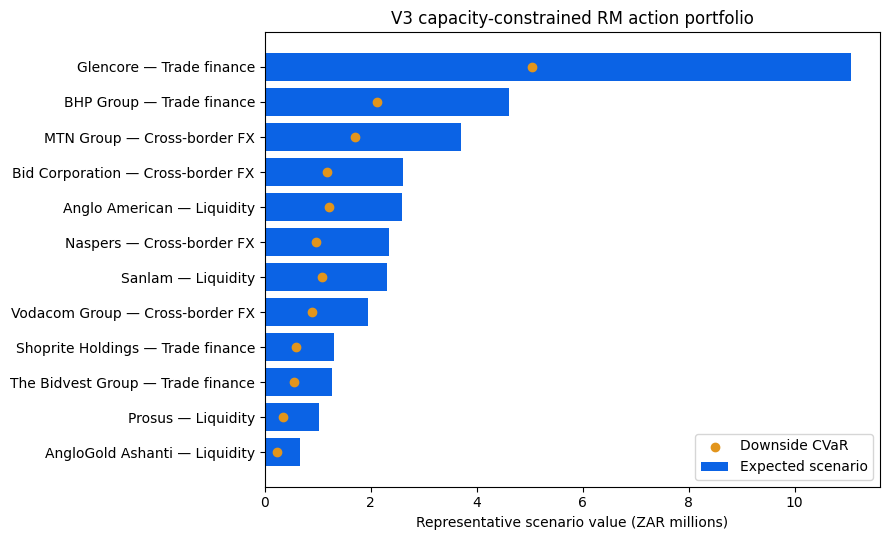

In [8]:
plot_actions = actions.sort_values('expected_scenario_value_zar')
plt.figure(figsize=(9, 5.5))
plt.barh(plot_actions['entity_name'] + ' — ' + plot_actions['product'], plot_actions['expected_scenario_value_zar']/1e6, color='#0B63E5', label='Expected scenario')
plt.scatter(plot_actions['downside_cvar_zar']/1e6, range(len(plot_actions)), color='#E2951C', label='Downside CVaR', zorder=3)
plt.xlabel('Representative scenario value (ZAR millions)')
plt.title('V3 capacity-constrained RM action portfolio')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Decision-Directed evidence acquisition

Evidence is queued only when expected portfolio-decision value exceeds acquisition cost and latency. `autonomous_external_retrieval=False` is a release invariant.

In [9]:
plan = v3['evidence_acquisition']
voi = pd.DataFrame(plan['selected'])
display(voi[['entity_id','product','evidence_type','expected_rank_flip_probability','expected_interval_width_reduction','net_value_of_information_zar','required_approval']])
print(f"Selected net VOI: R{voi['net_value_of_information_zar'].sum():,.0f}")
print('Autonomous external retrieval:', plan['autonomous_external_retrieval'])
assert not plan['autonomous_external_retrieval']
assert (voi['net_value_of_information_zar'] > 0).all()

,entity_id,product,evidence_type,expected_rank_flip_probability,expected_interval_width_reduction,net_value_of_information_zar,required_approval
0,E02,Trade finance,E3 multibank share observation,0.47,0.52,11950351.84,data-owner + client consent
1,E02,Trade finance,finance-approved product rate card,0.33,0.31,8218810.09,product finance + Treasury
2,E02,Trade finance,E2 client/RM attestation,0.23,0.22,5395267.43,RM + client attestation workflow
3,E01,Trade finance,E3 multibank share observation,0.47,0.52,5122452.13,data-owner + client consent
4,E16,Cross-border FX,E3 multibank share observation,0.47,0.52,3560025.01,data-owner + client consent
5,E01,Trade finance,finance-approved product rate card,0.33,0.31,3538200.40,product finance + Treasury
6,E03,Liquidity,E3 multibank share observation,0.47,0.52,2926482.14,data-owner + client consent
7,E10,Cross-border FX,E3 multibank share observation,0.47,0.52,2616633.54,data-owner + client consent


Selected net VOI: R43,328,223
Autonomous external retrieval: False


## 6. Rate/prior sensitivity — does Trade Finance remain dominant?

The frozen 3×3 benchmark is preserved for continuity and the 10,000-draw Latin-hypercube experiment reports rank and portfolio composition separately. Trade Finance remains first-ranked, but does not constitute a majority of the top ten or of the V3 action portfolio.

In [10]:
sens = v2['sensitivity']
product_summary = pd.DataFrame(sens['product_summary']).T.reset_index(names='product')
product_summary['median_economics_zar'] = product_summary['absolute_economics'].map(lambda x: x['p50'])
display(product_summary[['product','first_rank_frequency','mean_top10_share','majority_dominance_frequency','median_economics_zar']])
trade = sens['product_summary']['Trade finance']
print(f"Trade Finance first-rank frequency: {trade['first_rank_frequency']:.1%}")
print(f"Trade Finance mean top-10 share: {trade['mean_top10_share']:.1%}")
print(f"Trade Finance majority-dominance frequency: {trade['majority_dominance_frequency']:.1%}")
print(f"V3 action-portfolio share: {portfolio['product_counts']['Trade finance'] / portfolio['capacity']:.1%}")
assert trade['first_rank_frequency'] == 1.0
assert trade['majority_dominance_frequency'] == 0.0

,product,first_rank_frequency,mean_top10_share,majority_dominance_frequency,median_economics_zar
0,Collections,0.0,0.00018,0.0,12810289.68
1,Cross-border FX,0.0,0.51284,0.7969,57794850.26
2,Liquidity,0.0,0.23511,0.0,34793901.42
3,Payments,0.0,0.0,0.0,8173753.10
4,Trade finance,1.0,0.25187,0.0,53367591.92


Trade Finance first-rank frequency: 100.0%
Trade Finance mean top-10 share: 25.2%
Trade Finance majority-dominance frequency: 0.0%
V3 action-portfolio share: 33.3%


## 7. Evidence-cited brief — BHP Trade Finance

The deterministic claim compiler is the operational fallback and the only input allowed to a provider gateway. It separates observed, public, modelled and missing-evidence claims and prohibits measured-share, optimal-share and causal-uplift language.

In [11]:
brief = repository.brief('E01-trade-finance', repository.as_of)
display(Markdown(f"### {brief['headline']}\n\n**Decision:** {brief['decision']}"))
print(json.dumps(brief, indent=2, default=str))
assert brief['llm_contract']['external_tools'] is False
assert brief['llm_contract']['autonomous_action'] is False
assert 'measured competitor share' in brief['prohibited_phrases']

### BHP Group · Trade finance

**Decision:** Prioritise for governed RM review

{
  "opportunity_id": "E01-trade-finance",
  "headline": "BHP Group \u00b7 Trade finance",
  "decision": "Prioritise for governed RM review",
  "observed": {
    "activity_zar": 1444550118.15,
    "claim_class": "OBSERVED",
    "provenance": "SYN_BANK_SIMULATION"
  },
  "public_evidence": [
    {
      "fact_id": "BHP-2025-COST",
      "label": "BHP Annual Report 2025 p.118",
      "url": "https://www.bhp.com/-/media/documents/investors/annual-reports/2025/250819_bhpannualreport2025.pdf",
      "available_date": "2025-08-19",
      "approval_status": "APPROVED"
    },
    {
      "fact_id": "BHP-2025-INV-OPEN",
      "label": "BHP Annual Report 2025 p.139",
      "url": "https://www.bhp.com/-/media/documents/investors/annual-reports/2025/250819_bhpannualreport2025.pdf",
      "available_date": "2025-08-19",
      "approval_status": "APPROVED"
    },
    {
      "fact_id": "BHP-2025-INV-CLOSE",
      "label": "BHP Annual Report 2025 p.139",
      "url": "https://www.bhp.com/-/media/docu

## 8. Release conclusion

**Implemented and demo-ready:** entropy-constrained Shadow Wallet reconstruction; PU product-need model; Bayesian change-point/leakage signal; CVaR-aware RM portfolio; decision-directed evidence queue; governed claim compiler; V3 APIs; ABAC-protected decision lab; reproducible fixtures and tests.

**External gates that code cannot manufacture:** representative E3 multibank observations, approved pricing/FTP/capital/risk/cost inputs, bank AWS/Databricks/SSO/Unity Catalog/SIEM, approved live-provider evaluation, and supervised RM pilot/randomized trial.

The deployable demo is therefore a **client-facing representative decision lab**, not a bank-production or causal-value claim.